# 03. Transformers

Notebook para documentar el entrenamiento y comparación del transformer.


In [ ]:
## Objetivo del experimento con transformers

El objetivo de este cuaderno es documentar el entrenamiento y la evaluación de un modelo transformer en español para la tarea de detección binaria de toxicidad, utilizando como base BETO (`dccuchile/bert-base-spanish-wwm-cased`). Asimismo, se pretende comparar su rendimiento con el baseline clásico, con el fin de determinar si el uso de arquitecturas basadas en atención aporta una mejora significativa en la tarea planteada.

In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import json
import matplotlib.pyplot as plt

BASE_DIR = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
DATA_PROCESSED = BASE_DIR / "data" / "processed"
OUTPUTS_TABLES = BASE_DIR / "outputs" / "tables"
OUTPUTS_FIGURES = BASE_DIR / "outputs" / "figures"
OUTPUTS_METRICS = BASE_DIR / "outputs" / "metrics"

OUTPUTS_TABLES.mkdir(parents=True, exist_ok=True)
OUTPUTS_FIGURES.mkdir(parents=True, exist_ok=True)
OUTPUTS_METRICS.mkdir(parents=True, exist_ok=True)



In [2]:
with open(OUTPUTS_METRICS / "baseline_tfidf_logreg_metrics.json", "r", encoding="utf-8") as f:
    baseline = json.load(f)

with open(OUTPUTS_METRICS / "beto_toxicity_binary_metrics.json", "r", encoding="utf-8") as f:
    transformer = json.load(f)

comparison = pd.DataFrame([
    {"model":"baseline","split":"val","f1_macro":baseline["val"]["f1_macro"]},
    {"model":"baseline","split":"test","f1_macro":baseline["test"]["f1_macro"]},
    {"model":"baseline","split":"external_validation_detoxis","f1_macro":baseline["external_validation_detoxis"]["f1_macro"]},
    {"model":"beto","split":"val","f1_macro":transformer["val"]["f1_macro"]},
    {"model":"beto","split":"test","f1_macro":transformer["test"]["f1_macro"]},
    {"model":"beto","split":"external_validation_detoxis","f1_macro":transformer["external_validation_detoxis"]["f1_macro"]},
])
comparison.to_csv(OUTPUTS_TABLES / "model_comparison_metrics.csv", index=False, encoding="utf-8-sig")
comparison


,model,split,f1_macro
0,baseline,val,0.691647
1,baseline,test,0.701256
2,baseline,external_validation_detoxis,0.580494
3,beto,val,0.784151
4,beto,test,0.767148
5,beto,external_validation_detoxis,0.649337


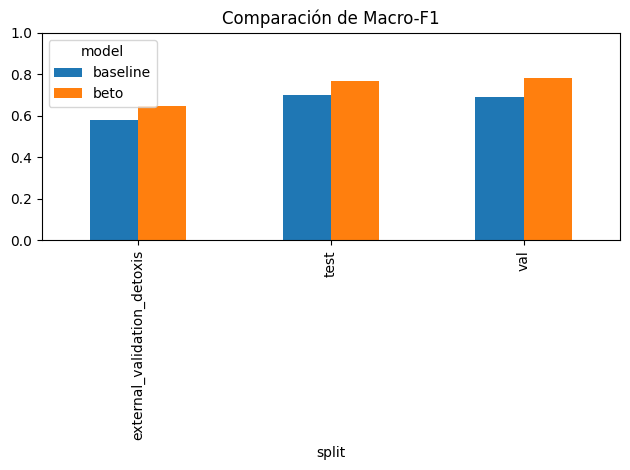

In [3]:
pivot = comparison.pivot(index="split", columns="model", values="f1_macro")
fig, ax = plt.subplots()
pivot.plot(kind="bar", ax=ax)
ax.set_title("Comparación de Macro-F1")
ax.set_ylim(0, 1)
fig.tight_layout()
fig.savefig(OUTPUTS_FIGURES / "transformer_vs_baseline_macro_f1.png", dpi=150, bbox_inches="tight")
plt.show()


In [ ]:
## Observaciones del entrenamiento transformer

El modelo transformer fue entrenado correctamente sobre el conjunto de entrenamiento compuesto por 7,182 instancias, utilizando validación interna con 1,539 ejemplos, prueba interna con 1,539 ejemplos y validación externa sobre 3,434 comentarios del corpus DETOXIS. El proceso de tokenización y preparación de los datos se completó de manera satisfactoria, y el entrenamiento se desarrolló durante tres épocas.

Durante el entrenamiento, el modelo mostró una evolución favorable. Al finalizar la primera época, se obtuvo un `eval_f1_macro` de 0.7792, acompañado de una `eval_accuracy` de 0.7869. En la segunda época se observó una ligera caída en validación, con un `eval_f1_macro` de 0.7657. Finalmente, en la tercera época el modelo recuperó y alcanzó el mejor resultado de validación, con un `eval_f1_macro` de 0.7842 y una `eval_accuracy` de 0.7901. El `train_loss` final reportado fue de 0.3392. :contentReference[oaicite:0]{index=0}

En la evaluación final, el modelo BETO alcanzó un Macro-F1 de 0.7842 en validación, 0.7671 en test y 0.6493 en validación externa. Estos valores superan de manera consistente al baseline TF-IDF + Logistic Regression, que había obtenido 0.6916 en validación, 0.7013 en test y 0.5805 en validación externa. En consecuencia, el transformer mejora tanto el rendimiento interno como la capacidad de generalización fuera del dominio principal del entrenamiento. :contentReference[oaicite:1]{index=1}

In [ ]:
## Síntesis comparativa

En comparación con el baseline, BETO mejora el Macro-F1 en validación (+0.0926), test (+0.0658) y validación externa (+0.0688). Estas mejoras confirman que el modelo transformer ofrece una representación más robusta del lenguaje tóxico en español y un mejor comportamiento ante cambios de dominio.

## Conclusiones del transformer

Los resultados obtenidos permiten concluir que BETO constituye una alternativa superior al baseline clásico para la detección binaria de toxicidad en español en el contexto de este proyecto. El modelo no solo mejora el rendimiento sobre los conjuntos internos, sino que también consigue una mejora relevante en validación externa, lo que indica una mejor capacidad de generalización.

La comparación experimental confirma que los transformadores son más adecuados para capturar matices semánticos y contextuales del lenguaje tóxico, especialmente en escenarios en los que existe variación de dominio. Por ello, BETO puede considerarse, en esta fase del proyecto, como el modelo de mejor desempeño y como candidato principal para su integración en la aplicación local desarrollada en Streamlit.
